In [1]:
# ============================================
# Notebook 2: OpenCV Basics
# Goal:
# Learn how to load, inspect, and display images using OpenCV.
# ============================================

# --- Key parameters ---
SHOW_AXES = False

# --- Imports ---
import numpy as np
import matplotlib.pyplot as plt
import cv2


In [73]:
# ============================================
# Capture an image from your camera
# Goal:
# Take one picture using the default camera and display it.
# ============================================

# --- Key parameters ---
CAMERA_INDEX = 0
WARMUP_FRAMES = 20
SAVE_PATH = "../images/captured_image.png"
DISPLAY_TITLE = "Captured image"

# --- Camera capture ---
cap = cv2.VideoCapture(CAMERA_INDEX)

if not cap.isOpened():
    print("Could not open camera.")
else:
    ret = False
    frame = None

    for _ in range(WARMUP_FRAMES):
        ret, frame = cap.read()

    cap.release()

    if not ret:
        print("Failed to capture image.")
    else:
        cv2.imwrite(SAVE_PATH, frame)
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        plt.imshow(rgb)
        plt.title(DISPLAY_TITLE)
        plt.axis("on" if SHOW_AXES else "off")
        plt.show()


OpenCV loads images in BGR format (not RGB).
shape (H, W, C): (746, 744, 3)
dtype: uint8


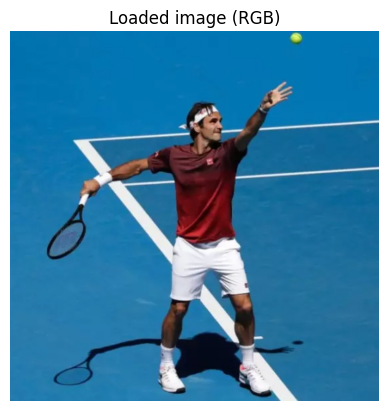

In [74]:
# ============================================
# Load a real image
# Goal:
# Understand how a color image is stored as a 3D array (H, W, C).
# ============================================

# --- Key parameters ---
IMAGE_PATH = "../images/captured_image.png"
DISPLAY_TITLE = "Loaded image (RGB)"

# --- Load image ---
bgr = cv2.imread(IMAGE_PATH)

if bgr is None:
    raise FileNotFoundError(f"Couldn't load {IMAGE_PATH}. Make sure the file exists.")

print("OpenCV loads images in BGR format (not RGB).")
print("shape (H, W, C):", bgr.shape)
print("dtype:", bgr.dtype)

rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

plt.imshow(rgb)
plt.title(DISPLAY_TITLE)
plt.axis("on" if SHOW_AXES else "off")
plt.show()


shape: (746, 744)
dtype: uint8


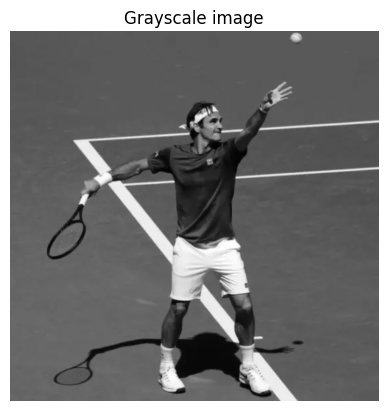

In [75]:
# ============================================
# Convert the image to grayscale
# Goal:
# See the difference between a color image and a 1-channel image.
# ============================================

# --- Key parameters ---
INPUT_IMAGE = bgr
DISPLAY_CMAP = "gray"
DISPLAY_TITLE = "Grayscale image"

# --- Convert to grayscale ---
gray = cv2.cvtColor(INPUT_IMAGE, cv2.COLOR_BGR2GRAY)

print("shape:", gray.shape)
print("dtype:", gray.dtype)

plt.imshow(gray, cmap=DISPLAY_CMAP)
plt.title(DISPLAY_TITLE)
plt.axis("on" if SHOW_AXES else "off")
plt.show()


Image loaded successfully.


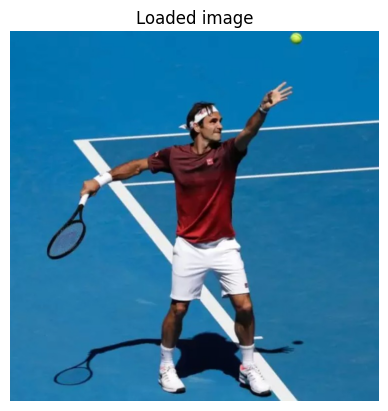

In [76]:
# ============================================
# 🧪 Example: Load and display an image (OpenCV)
# Goal:
# Learn how to load an image and display it correctly.
# ============================================

# --- Key parameters ---
EXAMPLE_IMAGE_PATH = "../images/captured_image.png"
DISPLAY_TITLE = "Loaded image"

# --- Load image from disk ---
img = cv2.imread(EXAMPLE_IMAGE_PATH)

if img is None:
    print("Image not found.")
else:
    print("Image loaded successfully.")

    # --- Convert BGR → RGB ---
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # --- Display the image ---
    plt.imshow(rgb)
    plt.title(DISPLAY_TITLE)
    plt.axis("on" if SHOW_AXES else "off")
    plt.show()

# ============================================
# 🧠 Checkpoint:
# - Why do we convert BGR to RGB before displaying with matplotlib?
# - What would happen if we skipped that conversion?
# ============================================


shape: (746, 744)
dtype: uint8


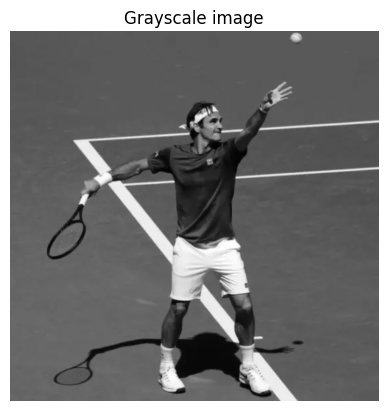

In [77]:
# ============================================
# 🧪 Example: Convert an image to grayscale
# Goal:
# Understand how to reduce a color image to 1 channel.
# ============================================

# --- Key parameters ---
INPUT_IMAGE = img
DISPLAY_CMAP = "gray"
DISPLAY_TITLE = "Grayscale image"

# --- Convert BGR image → Grayscale ---
gray = cv2.cvtColor(INPUT_IMAGE, cv2.COLOR_BGR2GRAY)

print("shape:", gray.shape)
print("dtype:", gray.dtype)

plt.imshow(gray, cmap=DISPLAY_CMAP)
plt.title(DISPLAY_TITLE)
plt.axis("on" if SHOW_AXES else "off")
plt.show()

# ============================================
# 🧠 Checkpoint:
# - What happened to the 3 color channels?
# - Why is the shape now (H, W) instead of (H, W, 3)?
# - What does each pixel value represent now?
# ============================================


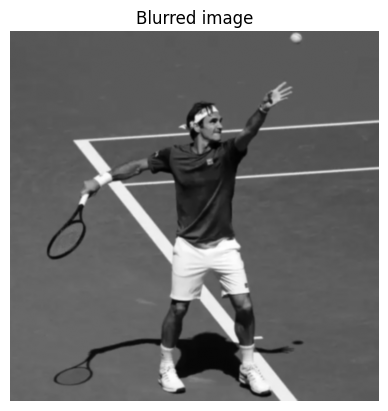

In [78]:
# ============================================
# 🧪 Example: Blur an image (noise reduction)
# Goal:
# Smooth the image before edge detection.
# ============================================

# --- Key parameters ---
INPUT_IMAGE = gray
KERNEL_SIZE = (5, 5)
SIGMA_X = 0
DISPLAY_CMAP = "gray"
DISPLAY_TITLE = "Blurred image"

# --- Apply Gaussian blur ---
blur = cv2.GaussianBlur(INPUT_IMAGE, KERNEL_SIZE, SIGMA_X)

plt.imshow(blur, cmap=DISPLAY_CMAP)
plt.title(DISPLAY_TITLE)
plt.axis("on" if SHOW_AXES else "off")
plt.show()

# ============================================
# 🧠 Checkpoint:
# - Why do we blur before detecting edges?
# - What might happen if we skip this step?
# ============================================


shape: (746, 744)
dtype: uint8
unique values: [  0 255]


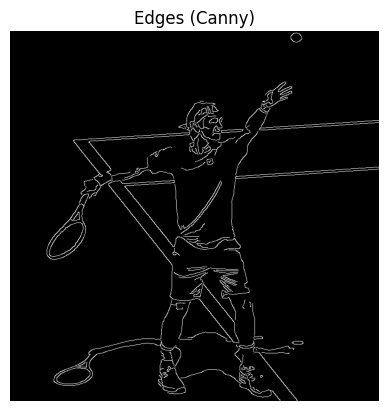

In [79]:
# ============================================
# 🧪 Example: Detect edges with Canny
# Goal:
# Identify strong intensity changes (object boundaries).
# ============================================

# --- Key parameters ---
INPUT_IMAGE = blur
LOW_THRESHOLD = 50
HIGH_THRESHOLD = 150
DISPLAY_CMAP = "gray"
DISPLAY_TITLE = "Edges (Canny)"

# --- Apply Canny edge detection ---
edges = cv2.Canny(INPUT_IMAGE, LOW_THRESHOLD, HIGH_THRESHOLD)

print("shape:", edges.shape)
print("dtype:", edges.dtype)
print("unique values:", np.unique(edges))

plt.imshow(edges, cmap=DISPLAY_CMAP)
plt.title(DISPLAY_TITLE)
plt.axis("on" if SHOW_AXES else "off")
plt.show()

# ============================================
# 🧠 Checkpoint:
# - What do the white pixels represent?
# - Why are there only two values (0 and 255)?
# - How might changing the thresholds affect the result?
# ============================================


In [80]:
# ============================================
# ✍️ STUDENT TASK: Canny edge detection
# Goal:
# Apply edge detection only for the strongest edges.
# ============================================

# --- Key parameters to fill in ---
INPUT_IMAGE = blur
LOW_THRESHOLD = None   # TODO: choose a lower threshold
HIGH_THRESHOLD = None  # TODO: choose a higher threshold
DISPLAY_CMAP = "gray"
DISPLAY_TITLE = "Edges (your version)"

# --- STUDENT TASK ---
# Replace None values above, then remove the next line.
if LOW_THRESHOLD is None or HIGH_THRESHOLD is None:
    raise NotImplementedError("STUDENT TASK: set LOW_THRESHOLD and HIGH_THRESHOLD before running this cell.")

edges = cv2.Canny(INPUT_IMAGE, LOW_THRESHOLD, HIGH_THRESHOLD)

print("shape:", edges.shape)
print("dtype:", edges.dtype)
print("unique values:", np.unique(edges))

plt.imshow(edges, cmap=DISPLAY_CMAP)
plt.title(DISPLAY_TITLE)
plt.axis("on" if SHOW_AXES else "off")
plt.show()

# ============================================
# 🧠 Checkpoint:
# - What input image should you use here?
# - What happens when thresholds are too low?
# - What happens when they are too high?
# ============================================


NotImplementedError: STUDENT TASK: set LOW_THRESHOLD and HIGH_THRESHOLD before running this cell.

In [ ]:
# ============================================
# 📹 Live Canny edge detection
# Goal:
# Show edges from webcam in real time
# ============================================

import cv2
import time
import numpy as np

# --- Parameters ---
CAMERA_INDEX = 0
DISPLAY_SECONDS = 10
WINDOW_NAME = "Live Canny Edges"

LOW_THRESHOLD = 50
HIGH_THRESHOLD = 150
FRAME_DELAY_MS = 1

cap = cv2.VideoCapture(CAMERA_INDEX)

if not cap.isOpened():
    print("Could not open camera.")
else:
    start_time = time.time()

    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                print("Could not read frame.")
                break

            # Mirror view (optional)
            frame = cv2.flip(frame, 1)

            # --- Convert to grayscale ---
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

            # --- Blur (important for cleaner edges) ---
            blur = cv2.GaussianBlur(gray, (5, 5), 0)

            # --- Canny edge detection ---
            edges = cv2.Canny(blur, LOW_THRESHOLD, HIGH_THRESHOLD)

            # Debug info (optional, prints once)
            # print("shape:", edges.shape)
            # print("dtype:", edges.dtype)
            # print("unique values:", np.unique(edges))

            # --- Display ---
            cv2.imshow(WINDOW_NAME, edges)

            # Stop after N seconds
            if time.time() - start_time > DISPLAY_SECONDS:
                break

            # Manual quit
            if cv2.waitKey(FRAME_DELAY_MS) & 0xFF == ord("q"):
                break

    finally:
        cap.release()
        cv2.waitKey(1)
        cv2.destroyAllWindows()
        cv2.waitKey(1)

shape: (746, 744)
dtype: uint8
unique values: [  0 255]


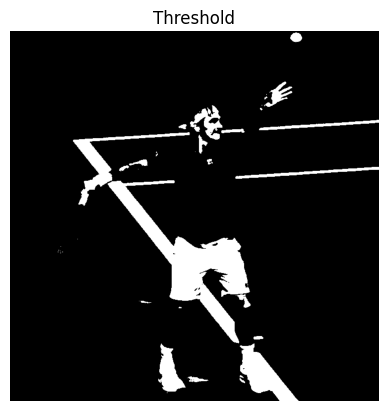

In [81]:
# ============================================
# 🧪 Example: Binary thresholding
# Goal:
# Convert a grayscale image into black & white.
# ============================================

# --- Key parameters ---
INPUT_IMAGE = gray
THRESHOLD_VALUE = 120
MAX_VALUE = 255
THRESHOLD_TYPE = cv2.THRESH_BINARY
DISPLAY_CMAP = "gray"
DISPLAY_TITLE = "Threshold"

# --- Apply thresholding ---
_, thresh = cv2.threshold(INPUT_IMAGE, THRESHOLD_VALUE, MAX_VALUE, THRESHOLD_TYPE)

print("shape:", thresh.shape)
print("dtype:", thresh.dtype)
print("unique values:", np.unique(thresh))

plt.imshow(thresh, cmap=DISPLAY_CMAP)
plt.title(DISPLAY_TITLE)
plt.axis("on" if SHOW_AXES else "off")
plt.show()

# ============================================
# 🧠 Checkpoint:
# - What does the value 120 control?
# - What happens if you increase or decrease it?
# - In what situations would thresholding be useful?
# ============================================


In [9]:
# ============================================
# 📹 Live binary thresholding
# Goal:
# Convert webcam grayscale feed into black & white
# ============================================

import cv2
import time
import numpy as np

# --- Parameters ---
CAMERA_INDEX = 0
DISPLAY_SECONDS = 10
WINDOW_NAME = "Live Threshold"

THRESHOLD_VALUE = 120
MAX_VALUE = 255
THRESHOLD_TYPE = cv2.THRESH_BINARY

FRAME_DELAY_MS = 1

cap = cv2.VideoCapture(CAMERA_INDEX)

if not cap.isOpened():
    print("Could not open camera.")
else:
    start_time = time.time()
    printed_debug = False

    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                print("Could not read frame.")
                break

            # Mirror view (optional)
            frame = cv2.flip(frame, 1)

            # --- Convert to grayscale ---
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

            # --- Apply threshold ---
            _, thresh = cv2.threshold(
                gray,
                THRESHOLD_VALUE,
                MAX_VALUE,
                THRESHOLD_TYPE
            )

            # Debug info (print once)
            if not printed_debug:
                print("shape:", thresh.shape)
                print("dtype:", thresh.dtype)
                print("unique values:", np.unique(thresh))
                printed_debug = True

            # --- Display ---
            cv2.imshow(WINDOW_NAME, thresh)

            # Stop after time
            if time.time() - start_time > DISPLAY_SECONDS:
                break

            if cv2.waitKey(FRAME_DELAY_MS) & 0xFF == ord("q"):
                break

    finally:
        cap.release()
        cv2.waitKey(1)
        cv2.destroyAllWindows()
        cv2.waitKey(1)

shape: (1080, 1920)
dtype: uint8
unique values: [0]


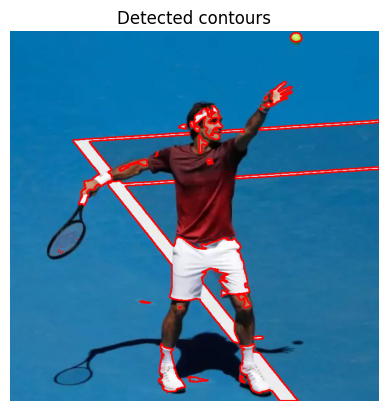

Contours found: 46


In [82]:
# ============================================
# 🧪 Example: Find and draw contours
# Goal:
# Detect object boundaries from a binary image.
# ============================================

# --- Key parameters ---
INPUT_BINARY_IMAGE = thresh
CONTOUR_RETRIEVAL_MODE = cv2.RETR_EXTERNAL
CONTOUR_APPROX_MODE = cv2.CHAIN_APPROX_SIMPLE
DRAW_COLOR = (255, 0, 0)  # red in RGB
DRAW_THICKNESS = 2
DISPLAY_TITLE = "Detected contours"

# --- Find contours ---
contours, _ = cv2.findContours(INPUT_BINARY_IMAGE, CONTOUR_RETRIEVAL_MODE, CONTOUR_APPROX_MODE)

# --- Draw contours on a copy of the original image ---
canvas = rgb.copy()
cv2.drawContours(canvas, contours, -1, DRAW_COLOR, DRAW_THICKNESS)

plt.imshow(canvas)
plt.title(DISPLAY_TITLE)
plt.axis("on" if SHOW_AXES else "off")
plt.show()

print("Contours found:", len(contours))

# ============================================
# 🧠 Checkpoint:
# - What does a contour represent?
# - Why do we use a binary image to find contours?
# - What kind of objects might create multiple contours?
# ============================================


In [6]:
# ============================================
# 📹 Live contour detection
# Goal:
# Detect and draw contours from webcam feed
# ============================================

import cv2
import time
import numpy as np

# --- Parameters ---
CAMERA_INDEX = 0
DISPLAY_SECONDS = 10
WINDOW_NAME = "Live Contours"

CONTOUR_RETRIEVAL_MODE = cv2.RETR_EXTERNAL
CONTOUR_APPROX_MODE = cv2.CHAIN_APPROX_SIMPLE

DRAW_COLOR = (0, 0, 255)   # Red (BGR in OpenCV)
DRAW_THICKNESS = 2

FRAME_DELAY_MS = 1

cap = cv2.VideoCapture(CAMERA_INDEX)

if not cap.isOpened():
    print("Could not open camera.")
else:
    start_time = time.time()

    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                print("Could not read frame.")
                break

            # Mirror view (optional)
            frame = cv2.flip(frame, 1)

            # --- Convert to grayscale ---
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

            # --- Blur to reduce noise ---
            blur = cv2.GaussianBlur(gray, (5, 5), 0)

            # --- Convert to binary image ---
            _, thresh = cv2.threshold(blur, 100, 255, cv2.THRESH_BINARY)

            # --- Find contours ---
            contours, _ = cv2.findContours(
                thresh,
                CONTOUR_RETRIEVAL_MODE,
                CONTOUR_APPROX_MODE
            )

            # --- Draw contours ---
            canvas = frame.copy()
            cv2.drawContours(canvas, contours, -1, DRAW_COLOR, DRAW_THICKNESS)

            # --- Display ---
            cv2.imshow(WINDOW_NAME, canvas)
            # Stop after time
            if time.time() - start_time > DISPLAY_SECONDS:
                break

            if cv2.waitKey(FRAME_DELAY_MS) & 0xFF == ord("q"):
                break

    finally:
        cap.release()
        cv2.waitKey(1)
        cv2.destroyAllWindows()
        cv2.waitKey(1)

Contours found: 0
Contours found: 20
Contours found: 23
Contours found: 10
Contours found: 17
Contours found: 13
Contours found: 24
Contours found: 16
Contours found: 12
Contours found: 12
Contours found: 18
Contours found: 29
Contours found: 26
Contours found: 30
Contours found: 34
Contours found: 33
Contours found: 34
Contours found: 33
Contours found: 29
Contours found: 31
Contours found: 36
Contours found: 40
Contours found: 32
Contours found: 35
Contours found: 36
Contours found: 33
Contours found: 49
Contours found: 43
Contours found: 45
Contours found: 43
Contours found: 39
Contours found: 38
Contours found: 29
Contours found: 29
Contours found: 26
Contours found: 28
Contours found: 30
Contours found: 26
Contours found: 25
Contours found: 28
Contours found: 33
Contours found: 30
Contours found: 32
Contours found: 35
Contours found: 37
Contours found: 35
Contours found: 38
Contours found: 38
Contours found: 42
Contours found: 36
Contours found: 37
Contours found: 35
Contours foun

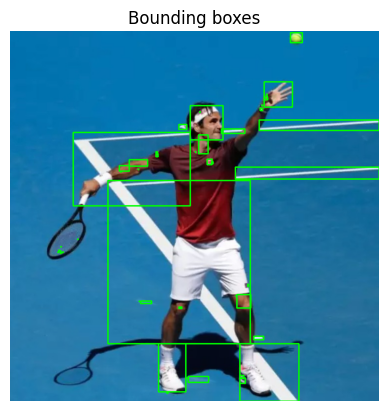

In [84]:
# ============================================
# 🧪 Example: Draw bounding boxes
# Goal:
# Enclose each detected object with a rectangle.
# ============================================

# --- Key parameters ---
INPUT_IMAGE = rgb.copy()
RECTANGLE_COLOR = (0, 255, 0)  # green in RGB
RECTANGLE_THICKNESS = 2
DISPLAY_TITLE = "Bounding boxes"

# --- Draw one bounding box per contour ---
canvas = INPUT_IMAGE.copy()

for c in contours:
    x, y, w, h = cv2.boundingRect(c)
    cv2.rectangle(
        canvas,
        (x, y),
        (x + w, y + h),
        RECTANGLE_COLOR,
        RECTANGLE_THICKNESS,
    )

plt.imshow(canvas)
plt.title(DISPLAY_TITLE)
plt.axis("on" if SHOW_AXES else "off")
plt.show()

# ============================================
# 🧠 Checkpoint:
# - What does each box represent?
# - How is a bounding box different from a contour?
# - When would bounding boxes be preferred over contours?
# ============================================


In [8]:
# ============================================
# 📹 Live bounding box detection
# Goal:
# Draw a rectangle around each detected object
# ============================================

import cv2
import time

# --- Parameters ---
CAMERA_INDEX = 0
DISPLAY_SECONDS = 20
WINDOW_NAME = "Live Bounding Boxes"

RECTANGLE_COLOR = (0, 255, 0)   # Green (BGR)
RECTANGLE_THICKNESS = 2

MIN_AREA = 500                  # Ignore small noise
FRAME_DELAY_MS = 1

cap = cv2.VideoCapture(CAMERA_INDEX)

if not cap.isOpened():
    print("Could not open camera.")
else:
    start_time = time.time()

    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                print("Could not read frame.")
                break

            # Mirror view (optional)
            frame = cv2.flip(frame, 1)

            # --- Preprocessing ---
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            blur = cv2.GaussianBlur(gray, (5, 5), 0)

            # --- Binary image (you can switch to Canny if preferred) ---
            _, thresh = cv2.threshold(blur, 100, 255, cv2.THRESH_BINARY)

            # --- Find contours ---
            contours, _ = cv2.findContours(
                thresh,
                cv2.RETR_EXTERNAL,
                cv2.CHAIN_APPROX_SIMPLE
            )

            # --- Draw bounding boxes ---
            canvas = frame.copy()

            count = 0
            for c in contours:
                if cv2.contourArea(c) < MIN_AREA:
                    continue

                x, y, w, h = cv2.boundingRect(c)

                cv2.rectangle(
                    canvas,
                    (x, y),
                    (x + w, y + h),
                    RECTANGLE_COLOR,
                    RECTANGLE_THICKNESS,
                )
                count += 1

            # --- Display ---
            cv2.imshow(WINDOW_NAME, canvas)

            # Stop after time
            if time.time() - start_time > DISPLAY_SECONDS:
                break

            if cv2.waitKey(FRAME_DELAY_MS) & 0xFF == ord("q"):
                break

    finally:
        cap.release()
        cv2.waitKey(1)
        cv2.destroyAllWindows()
        cv2.waitKey(1)

Boxes drawn: 0
Boxes drawn: 9
Boxes drawn: 6
Boxes drawn: 6
Boxes drawn: 7
Boxes drawn: 4
Boxes drawn: 3
Boxes drawn: 3
Boxes drawn: 3
Boxes drawn: 3
Boxes drawn: 4
Boxes drawn: 4
Boxes drawn: 5
Boxes drawn: 6
Boxes drawn: 4
Boxes drawn: 5
Boxes drawn: 5
Boxes drawn: 5
Boxes drawn: 9
Boxes drawn: 8
Boxes drawn: 6
Boxes drawn: 6
Boxes drawn: 6
Boxes drawn: 7
Boxes drawn: 5
Boxes drawn: 5
Boxes drawn: 5
Boxes drawn: 6
Boxes drawn: 4
Boxes drawn: 6
Boxes drawn: 6
Boxes drawn: 4
Boxes drawn: 3
Boxes drawn: 6
Boxes drawn: 4
Boxes drawn: 5
Boxes drawn: 4
Boxes drawn: 6
Boxes drawn: 5
Boxes drawn: 4
Boxes drawn: 6
Boxes drawn: 3
Boxes drawn: 3
Boxes drawn: 3
Boxes drawn: 3
Boxes drawn: 6
Boxes drawn: 4
Boxes drawn: 4
Boxes drawn: 4
Boxes drawn: 4
Boxes drawn: 2
Boxes drawn: 2
Boxes drawn: 4
Boxes drawn: 2
Boxes drawn: 2
Boxes drawn: 2
Boxes drawn: 2
Boxes drawn: 3
Boxes drawn: 3
Boxes drawn: 2
Boxes drawn: 2
Boxes drawn: 4
Boxes drawn: 5
Boxes drawn: 5
Boxes drawn: 5
Boxes drawn: 5
Boxes draw

In [10]:
# ============================================
# 📹 Live motion trail effect 
# Goal:
# Leave a fading trail mainly on moving areas.
# ============================================

import cv2
import time
from collections import deque

# --- Parameters ---
CAMERA_INDEX = 0
DISPLAY_SECONDS = 10
WINDOW_NAME = "Motion Trail"

TRAIL_LENGTH = 10
THRESHOLD = 25           # Motion sensitivity
BLUR_SIZE = 7            # Must be odd
MIN_AREA = 500           # Ignore tiny moving regions
FRAME_DELAY_MS = 1

cap = cv2.VideoCapture(CAMERA_INDEX)

if not cap.isOpened():
    print("Could not open camera.")
else:
    start_time = time.time()
    prev_gray = None
    trail_buffer = deque(maxlen=TRAIL_LENGTH)

    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                print("Could not read frame from camera.")
                break

            frame = cv2.flip(frame, 1)
            display = frame.copy()

            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            gray = cv2.GaussianBlur(gray, (BLUR_SIZE, BLUR_SIZE), 0)

            if prev_gray is not None:
                # Difference between current and previous frame
                diff = cv2.absdiff(prev_gray, gray)
                _, motion_mask = cv2.threshold(diff, THRESHOLD, 255, cv2.THRESH_BINARY)

                # Clean mask
                kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
                motion_mask = cv2.morphologyEx(motion_mask, cv2.MORPH_OPEN, kernel)
                motion_mask = cv2.dilate(motion_mask, kernel, iterations=2)

                # Remove tiny areas
                contours, _ = cv2.findContours(motion_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                clean_mask = motion_mask.copy()
                clean_mask[:] = 0

                for cnt in contours:
                    if cv2.contourArea(cnt) >= MIN_AREA:
                        cv2.drawContours(clean_mask, [cnt], -1, 255, thickness=cv2.FILLED)

                # Save only moving parts of the frame
                moving_part = cv2.bitwise_and(frame, frame, mask=clean_mask)
                trail_buffer.appendleft((moving_part, clean_mask.copy()))

            # Draw past moving parts with fade
            n = len(trail_buffer)
            for i, (trail_img, trail_mask) in enumerate(trail_buffer):
                alpha = (n - i) / (n + 1) * 0.6

                mask_3 = cv2.merge([trail_mask, trail_mask, trail_mask])
                masked_trail = cv2.bitwise_and(trail_img, mask_3)

                display = cv2.addWeighted(display, 1.0, masked_trail, alpha, 0)

            prev_gray = gray

            cv2.imshow(WINDOW_NAME, display)

            if time.time() - start_time > DISPLAY_SECONDS:
                break

            if cv2.waitKey(FRAME_DELAY_MS) & 0xFF == ord("q"):
                break

    finally:
        cap.release()
        cv2.waitKey(1)
        cv2.destroyAllWindows()
        cv2.waitKey(1)